# Unit07 Example 06 - 二元蒸餾塔設計計算（非線性方程式逐級求解）

本範例以**苯-甲苯（Benzene-Toluene）二元蒸餾系統**為例，介紹如何利用 `scipy.optimize.root_scalar()` 結合**泡點計算**，實作 **McCabe-Thiele 逐級法**求解理論板數，並計算各板的氣液相組成與溫度分布。

## 目標

- 建立**泡點方程式**，以非線性方程式求解在給定液相組成下的平衡溫度
- 利用 **Antoine 方程式**計算飽和蒸氣壓，實作 VLE（氣液相平衡）曲線
- 以 **McCabe-Thiele 操作線方程式**建立精餾段與汽提段操作線
- 使用**逐級步進算法（Plate-by-Plate Stepping）**計算理論板數與進料板位置
- 繪製完整 **x-y 圖**（含平衡曲線、操作線、板級步進）及**溫度分布圖**
- 進行**回流比參數研究**，分析回流比對理論板數的影響

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import root_scalar
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定

**蒸餾系統說明**

在連續蒸餾操作中，進料為**苯-甲苯（Benzene-Toluene）二元混合物**，苯為輕成分（high volatility），系統在大氣壓下操作。此系統為化工教學的經典二元蒸餾案例，具有完整的 VLE 數據，適合示範 McCabe-Thiele 圖解法的數值實現。

**設計規格：**

| 設計變數 | 符號 | 數值 | 說明 |
|---------|------|------|------|
| 操作壓力 | $P$ | 760 mmHg | 大氣壓 |
| 進料苯摩爾分率 | $z_F$ | 0.40 | 40 mol% 苯 |
| 塔頂產品苯摩爾分率 | $x_D$ | 0.92 | 92 mol% 苯 |
| 塔底產品苯摩爾分率 | $x_B$ | 0.05 | 5 mol% 苯 |
| 進料熱狀態 | $q$ | 1.0 | 飽和液進料 |
| 回流比 | $R = L/D$ | 2.5 | 設計回流比 |

**待求解問題：**

1. 在給定液相組成 $x$ 下，求解泡點溫度 $T_{bp}(x)$ （**單變數非線性方程式**）
2. 由泡點方程式得出平衡氣相組成 $y^* = y^*(x)$ ，建立 VLE 曲線
3. 利用 McCabe-Thiele 步進法計算**理論板數** $N$ 與**最佳進料板位置** $N_F$

**物料平衡（Overall Material Balance）：**

$$
F = D + B
$$

$$
F \cdot z_F = D \cdot x_D + B \cdot x_B
$$

以 $F = 100$ mol/h 為基準，可求得 $D$ 與 $B$。

In [3]:
# ========================================
# 系統參數設定
# ========================================

# 操作條件
P_total = 760.0   # 操作壓力 [mmHg]

# 設計規格
z_F  = 0.40   # 進料苯摩爾分率 [-]
x_D  = 0.92   # 塔頂苯摩爾分率 [-]
x_B  = 0.05   # 塔底苯摩爾分率 [-]
q    = 1.0    # 進料熱狀態 (q=1: 飽和液進料)
R    = 2.5    # 回流比 L/D [-]

# Antoine 係數 (P in mmHg, T in °C)
# 苯 (Benzene):  log10(P) = A - B/(C+T)
ANTOINE_BEN = (6.90565, 1211.033, 220.790)
# 甲苯 (Toluene): log10(P) = A - B/(C+T)
ANTOINE_TOL = (6.95334, 1343.943, 219.377)

# 物料平衡（基準 F=100 mol/h）
F = 100.0
D = F * (z_F - x_B) / (x_D - x_B)
B = F - D

print("=" * 55)
print("  苯-甲苯蒸餾塔設計參數")
print("=" * 55)
print(f"  操作壓力     P       = {P_total:.1f} mmHg")
print(f"  進料組成     z_F     = {z_F:.2f}")
print(f"  塔頂規格     x_D     = {x_D:.2f}")
print(f"  塔底規格     x_B     = {x_B:.2f}")
print(f"  進料熱狀態   q       = {q:.1f}  (飽和液進料)")
print(f"  回流比       R       = {R:.1f}")
print("-" * 55)
print(f"  進料量       F       = {F:.1f} mol/h")
print(f"  塔頂採出量   D       = {D:.2f} mol/h")
print(f"  塔底採出量   B       = {B:.2f} mol/h")
print(f"  回收率（苯） η_D     = {D*x_D/(F*z_F)*100:.1f}%")
print("=" * 55)

  苯-甲苯蒸餾塔設計參數
  操作壓力     P       = 760.0 mmHg
  進料組成     z_F     = 0.40
  塔頂規格     x_D     = 0.92
  塔底規格     x_B     = 0.05
  進料熱狀態   q       = 1.0  (飽和液進料)
  回流比       R       = 2.5
-------------------------------------------------------
  進料量       F       = 100.0 mol/h
  塔頂採出量   D       = 40.23 mol/h
  塔底採出量   B       = 59.77 mol/h
  回收率（苯） η_D     = 92.5%


---
### 3. VLE 計算：泡點方程式

**Antoine 方程式（P in mmHg，T in °C）：**

$$
\log_{10} P_i^{sat} = A_i - \frac{B_i}{C_i + T}
$$

| 成分 | A | B | C | T 範圍 (°C) |
|------|---------|---------|---------|------------|
| 苯（Benzene） | 6.90565 | 1211.033 | 220.790 | 8 ~ 103 |
| 甲苯（Toluene） | 6.95334 | 1343.943 | 219.377 | 10 ~ 136 |

**Raoult's Law（理想溶液）：**

$$
y_i = \frac{x_i \cdot P_i^{sat}(T)}{P}
$$

**泡點方程式（待求非線性方程式）：**

$$
f(T) = x_A \cdot P_A^{sat}(T) + x_B \cdot P_B^{sat}(T) - P = 0
$$

在給定液相組成 $x_A$ 下，求解泡點溫度 $T_{bp}$ ，然後計算平衡氣相組成：

$$
y_A^* = \frac{x_A \cdot P_A^{sat}(T_{bp})}{P}
$$

**求解步驟：**
1. 對每個 $x_A \in [0, 1]$，用 `root_scalar(brentq)` 求解泡點 $T_{bp}(x_A)$
2. 代回計算 $y_A^*(x_A)$ ，構建完整的 VLE 曲線

In [4]:
def antoine_psat(T, A, B, C):
    """計算飽和蒸氣壓 (Antoine 方程式)
    Parameters: T [°C], 返回 P [mmHg]
    """
    return 10.0 ** (A - B / (C + T))


def bubble_point_T(x_A, P=P_total):
    """
    求解泡點溫度（Bubble Point Temperature）
    給定液相苯摩爾分率 x_A, 求滿足 Raoult's Law 的溫度 T

    方程式: f(T) = x_A * P_A_sat(T) + (1-x_A) * P_B_sat(T) - P = 0
    """
    def f_bp(T):
        PA = antoine_psat(T, *ANTOINE_BEN)
        PB = antoine_psat(T, *ANTOINE_TOL)
        return x_A * PA + (1.0 - x_A) * PB - P

    # 苯沸點~80°C，甲苯沸點~110°C，泡點在此範圍內
    sol = root_scalar(f_bp, method='brentq', bracket=[70.0, 125.0])
    return sol.root


def equilibrium_y(x_A, T_bp):
    """
    計算平衡氣相苯摩爾分率 y_A* (Raoult's Law)
    """
    PA = antoine_psat(T_bp, *ANTOINE_BEN)
    return x_A * PA / P_total


# ── 建立 VLE 曲線 ────────────────────────────────────────────
x_vle = np.linspace(0.0, 1.0, 101)
T_vle = np.array([bubble_point_T(xi) for xi in x_vle])
y_vle = np.array([equilibrium_y(xi, Ti) for xi, Ti in zip(x_vle, T_vle)])

# ── 驗證輸出 ─────────────────────────────────────────────────
print("VLE 計算驗證（苯-甲苯，760 mmHg）")
print("-" * 55)
print(f"  {'x_benzene':>10} {'T_bp (°C)':>12} {'y_benzene*':>12}")
print("-" * 55)
for xi in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    Ti = bubble_point_T(xi)
    yi = equilibrium_y(xi, Ti)
    print(f"  {xi:>10.2f} {Ti:>12.4f} {yi:>12.4f}")
print("-" * 55)
print(f"\n✓ 苯純沸點:  T(x=1) = {bubble_point_T(1.0):.2f} °C  (文獻值: 80.10°C)")
print(f"✓ 甲苯純沸點: T(x=0) = {bubble_point_T(0.0):.2f} °C  (文獻值: 110.63°C)")

VLE 計算驗證（苯-甲苯，760 mmHg）
-------------------------------------------------------
   x_benzene    T_bp (°C)   y_benzene*
-------------------------------------------------------
        0.00     110.6253       0.0000
        0.20     102.1025       0.3761
        0.40      95.1418       0.6219
        0.60      89.3285       0.7905
        0.80      84.3802       0.9110
        1.00      80.1000       1.0000
-------------------------------------------------------

✓ 苯純沸點:  T(x=1) = 80.10 °C  (文獻值: 80.10°C)
✓ 甲苯純沸點: T(x=0) = 110.63 °C  (文獻值: 110.63°C)


---
### 4. McCabe-Thiele 圖解法：操作線

**精餾段操作線（Rectifying Section Operating Line）：**

對精餾段（進料板以上）做包含塔頂的物料平衡，得到：

$$
y_{n+1} = \frac{R}{R+1} \cdot x_n + \frac{x_D}{R+1}
$$

- 斜率 $= R/(R+1)$ ，截距 $= x_D/(R+1)$
- 起始點 $(x_D,\ x_D)$ （全凝器）

**進料 q 線（Feed q-Line）：**

$$
y = \frac{q}{q-1} x - \frac{z_F}{q-1}
$$

當 $q = 1$ （飽和液進料）時，q 線為**垂直線** $x = z_F$ 。

**汽提段操作線（Stripping Section Operating Line）：**

通過點 $(x_B,\ x_B)$ 及精餾段操作線與 q 線的交點 $(x_{int},\ y_{int})$ ：

$$
y = \frac{y_{int} - x_B}{x_{int} - x_B} \cdot (x - x_B) + x_B
$$

**最小回流比 $R_{min}$（Underwood 方程式近似）：**

當操作線通過 q 線與平衡曲線的交點時，對應 $R_{min}$ 。可由圖形法求得交點 $(x_{int},\ y_{int}^*)$ ：

$$
R_{min} = \frac{x_D - y_{int}^*}{y_{int}^* - x_{int}}
$$

本範例回流比 $R = 2.5$ ，需確認 $R > R_{min}$ 。

操作線計算結果
  最小回流比   R_min  = 1.3439
  設計回流比   R      = 2.5  (= 1.86 × R_min)
  Pinch 點     (x, y) = (0.4000, 0.6219)
-------------------------------------------------------
  精餾段操作線 斜率 = 0.7143
              截距 = 0.2629
  汽提段操作線 斜率 = 1.4245
              截距 = -0.0212
  操作線交點   (x_int, y_int) = (0.4000, 0.5486)


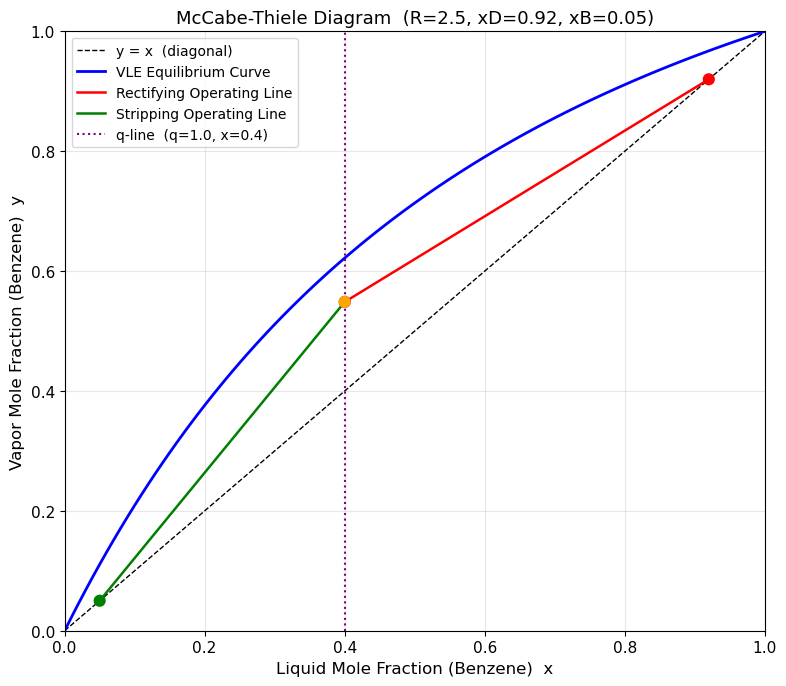

✓ 已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06\figs\fig_01_mccabe_thiele_base.png


In [5]:
def get_operating_lines(x_D, x_B, z_F, R, q=1.0):
    """
    計算精餾段、汽提段操作線及進料線交點

    Returns
    -------
    dict with keys:
      rect_slope, rect_intercept  : 精餾段操作線係數
      strip_slope, strip_intercept: 汽提段操作線係數
      x_int, y_int                : 操作線交點（精餾/汽提）
    """
    # 精餾段操作線
    rect_slope     = R / (R + 1.0)
    rect_intercept = x_D / (R + 1.0)

    # q 線與精餾段操作線的交點 (x_int, y_int)
    if abs(q - 1.0) < 1e-8:
        # q=1：垂直線 x = z_F
        x_int = z_F
        y_int = rect_slope * z_F + rect_intercept
    else:
        # q 線: y = q/(q-1)*x - zF/(q-1)
        q_slope     = q / (q - 1.0)
        q_intercept = -z_F / (q - 1.0)
        x_int = (rect_intercept - q_intercept) / (q_slope - rect_slope)
        y_int = rect_slope * x_int + rect_intercept

    # 汽提段操作線（通過 (x_B, x_B) 和 (x_int, y_int)）
    strip_slope     = (y_int - x_B) / (x_int - x_B)
    strip_intercept = x_B - strip_slope * x_B   # = x_B * (1 - strip_slope)

    return {
        'rect_slope': rect_slope, 'rect_intercept': rect_intercept,
        'strip_slope': strip_slope, 'strip_intercept': strip_intercept,
        'x_int': x_int, 'y_int': y_int
    }


def calc_R_min(x_D, z_F, q=1.0):
    """
    計算最小回流比 R_min（圖形法：q 線與平衡曲線的交點）
    """
    if abs(q - 1.0) < 1e-8:
        # q=1：q 線 x=z_F，找平衡曲線在 x=z_F 的 y*
        T_q = bubble_point_T(z_F)
        y_star = equilibrium_y(z_F, T_q)
        x_q_int = z_F
    else:
        # 一般情況：數值求解交點
        def eq_qline(x):
            T = bubble_point_T(x)
            y_eq = equilibrium_y(x, T)
            y_qline = q / (q - 1.0) * x - z_F / (q - 1.0)
            return y_eq - y_qline
        sol = root_scalar(eq_qline, bracket=[z_F * 0.5, z_F * 1.5])
        x_q_int = sol.root
        T_q = bubble_point_T(x_q_int)
        y_star = equilibrium_y(x_q_int, T_q)

    R_min = (x_D - y_star) / (y_star - x_q_int)
    return R_min, x_q_int, y_star


# ── 計算操作線 ────────────────────────────────────────────────
ol = get_operating_lines(x_D, x_B, z_F, R, q)
R_min, x_pinch, y_pinch = calc_R_min(x_D, z_F, q)

print("操作線計算結果")
print("=" * 55)
print(f"  最小回流比   R_min  = {R_min:.4f}")
print(f"  設計回流比   R      = {R:.1f}  (= {R/R_min:.2f} × R_min)")
print(f"  Pinch 點     (x, y) = ({x_pinch:.4f}, {y_pinch:.4f})")
print("-" * 55)
print(f"  精餾段操作線 斜率 = {ol['rect_slope']:.4f}")
print(f"              截距 = {ol['rect_intercept']:.4f}")
print(f"  汽提段操作線 斜率 = {ol['strip_slope']:.4f}")
print(f"              截距 = {ol['strip_intercept']:.4f}")
print(f"  操作線交點   (x_int, y_int) = ({ol['x_int']:.4f}, {ol['y_int']:.4f})")
print("=" * 55)

# ── 繪製 x-y 圖（平衡曲線 + 操作線）────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# 45° 對角線
ax.plot([0, 1], [0, 1], 'k--', lw=1.0, label='y = x  (diagonal)')
# 平衡曲線
ax.plot(x_vle, y_vle, 'b-', lw=2.0, label='VLE Equilibrium Curve')
# 精餾段操作線
x_rect = np.linspace(ol['x_int'], x_D, 50)
y_rect = ol['rect_slope'] * x_rect + ol['rect_intercept']
ax.plot(x_rect, y_rect, 'r-', lw=1.8, label='Rectifying Operating Line')
# 汽提段操作線
x_strip = np.linspace(x_B, ol['x_int'], 50)
y_strip = ol['strip_slope'] * x_strip + ol['strip_intercept']
ax.plot(x_strip, y_strip, 'g-', lw=1.8, label='Stripping Operating Line')
# q 線（飽和液：垂直線 x=z_F）
ax.axvline(z_F, color='purple', ls=':', lw=1.5, label=f'q-line  (q={q}, x={z_F})')
# 關鍵點
ax.scatter([x_D, x_B, z_F, ol['x_int']],
           [x_D, x_B, ol['y_int'], ol['y_int']],
           color=['red','green','purple','orange'], zorder=5, s=60)

ax.set_xlabel('Liquid Mole Fraction (Benzene)  x')
ax.set_ylabel('Vapor Mole Fraction (Benzene)  y')
ax.set_title(f'McCabe-Thiele Diagram  (R={R}, xD={x_D}, xB={x_B})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper left')

fig.tight_layout()
fig_path = FIG_DIR / 'fig_01_mccabe_thiele_base.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 已儲存: {fig_path}")

---
### 5. 逐級計算（Plate-by-Plate Stepping）

**McCabe-Thiele 步進演算法原理：**

在 x-y 圖上交替在**平衡曲線**和**操作線**之間畫水平線和垂直線，每一個「台階」代表一塊**理論板（Theoretical Plate）**。

**步進流程（由塔頂向塔底）：**

1. 起始點：$(x_D,\ x_D)$ （全凝器，塔頂液相 = 迴流液相）
2. **向左**水平至平衡曲線：找 $x_n$ 使 $y^*(x_n) = y_n$ （求解非線性方程式）
3. **向下**垂直至操作線：得到下一塊板的蒸氣 $y_{n+1} = f_{op}(x_n)$
4. 重複步驟 2-3，當板在 $x_{int}$ 左邊時切換至汽提段操作線
5. 當 $x_n \leq x_B$ 時停止計數

**關鍵非線性方程式求解（步驟 2）：**

給定目標蒸氣組成 $y_{target}$ ，求液相組成 $x$ ：

$$
g(x) = y^*(x) - y_{target} = \mathrm{equilibrium\_y}(x,\ T_{bp}(x)) - y_{target} = 0
$$

此方程式為複合非線性方程式：先對每個 $x$ 求解泡點 $T_{bp}(x)$ （第一層非線性），再代入計算 $y^*(x)$ （Raoult's Law），最終以 `root_scalar` 求解 $g(x) = 0$ （第二層非線性）。

**最佳進料板（Optimal Feed Plate）：**

當步進點 $x_n$ 接近且剛通過 $x_{int}$ 時，切換至汽提段操作線，此板即為最佳進料板。

  McCabe-Thiele Plate-by-Plate Results
  Total theoretical stages : 10
  Optimal feed plate       : 5
  (Condenser stage 1, reboiler stage 10)
--------------------------------------------------
   Stage    x (liquid)     y (vapor)
--------------------------------------------------
       1        0.8177        0.9200
       2        0.6857        0.8469
       3        0.5486        0.7526
       4        0.4337        0.6547
       5        0.3532        0.5727
       6        0.2765        0.4819
       7        0.1977        0.3727
       8        0.1284        0.2604
       9        0.0752        0.1617
      10        0.0383        0.0859


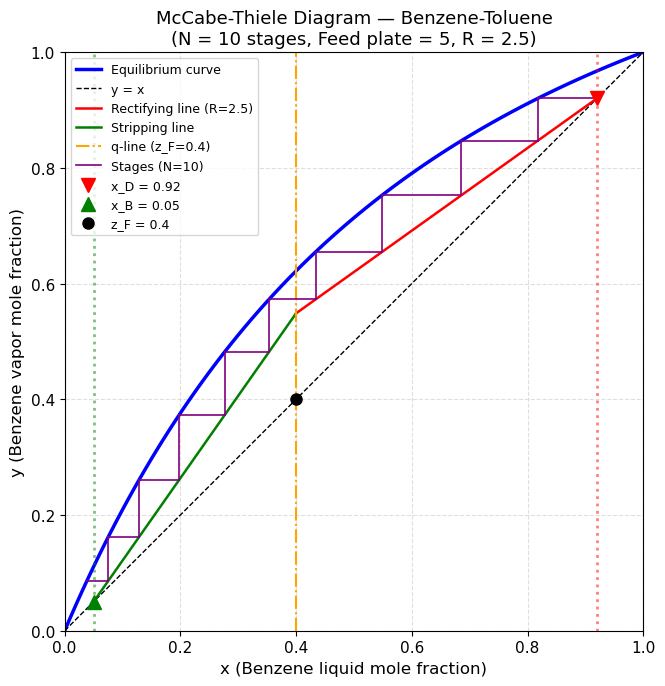

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06\figs\fig_02_mccabe_thiele_steps.png


In [6]:
# ============================================================
# §5 Plate-by-Plate Stepping Algorithm
# ============================================================

def find_x_from_y_eq(y_target, tol=1e-8):
    """
    Given vapor composition y_target on the equilibrium curve,
    find the corresponding liquid composition x by solving:
        equilibrium_y(x, bubble_point_T(x)) - y_target = 0
    This is a two-level nested nonlinear equation.
    """
    def eq(x):
        T = bubble_point_T(x)
        return equilibrium_y(x, T) - y_target

    sol = root_scalar(eq, bracket=[1e-4, 1 - 1e-4], method='brentq', xtol=tol)
    return sol.root


def step_mccabe_thiele(x_D, x_B, z_F, R, q=1.0, max_stages=100):
    """
    Perform McCabe-Thiele plate-stepping from top (y=x_D) to bottom.
    Returns:
        stages     : list of {'n', 'x', 'y'} for each theoretical plate
        N_stages   : total number of theoretical stages (incl. reboiler)
        feed_plate : optimal feed plate number
    """
    ol = get_operating_lines(x_D, x_B, z_F, R, q)
    rect_slope      = ol['rect_slope']
    rect_intercept  = ol['rect_intercept']
    strip_slope     = ol['strip_slope']
    strip_intercept = ol['strip_intercept']
    x_int           = ol['x_int']

    stages = []
    y = x_D           # start at top: y = x_D (total condenser)
    feed_plate = None
    n = 0

    for _ in range(max_stages):
        # Step 1: horizontal to equilibrium curve — find x from y=y_target
        x = find_x_from_y_eq(y)
        n += 1
        stages.append({'n': n, 'x': x, 'y': y})

        # Check termination: below bottoms specification
        if x <= x_B:
            break

        # Step 2: vertical to operating line — determine next y
        if x >= x_int:
            # Still in rectifying section
            y_next = rect_slope * x + rect_intercept
        else:
            # Crossed feed point — switch to stripping section
            if feed_plate is None:
                feed_plate = n
            y_next = strip_slope * x + strip_intercept

        y = y_next

    N_stages = n
    if feed_plate is None:
        feed_plate = n  # fallback

    return stages, N_stages, feed_plate


# ── Run stepping ──────────────────────────────────────────
stages, N_stages, feed_plate = step_mccabe_thiele(
    x_D, x_B, z_F, R, q
)

print("=" * 50)
print("  McCabe-Thiele Plate-by-Plate Results")
print("=" * 50)
print(f"  Total theoretical stages : {N_stages}")
print(f"  Optimal feed plate       : {feed_plate}")
print(f"  (Condenser stage 1, reboiler stage {N_stages})")
print("-" * 50)
print(f"  {'Stage':>6}  {'x (liquid)':>12}  {'y (vapor)':>12}")
print("-" * 50)
for s in stages:
    print(f"  {s['n']:>6}  {s['x']:>12.4f}  {s['y']:>12.4f}")
print("=" * 50)

# ── Full McCabe-Thiele diagram with stepping ──────────────
ol = get_operating_lines(x_D, x_B, z_F, R, q)

fig, ax = plt.subplots(figsize=(7, 7))

# Equilibrium curve
ax.plot(x_vle, y_vle, 'b-', linewidth=2.5, label='Equilibrium curve')

# Diagonal y=x
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='y = x')

# Rectifying operating line
ax.plot([ol['x_int'], x_D], [ol['y_int'], x_D], 'r-', linewidth=1.8,
        label=f'Rectifying line (R={R})')

# Stripping operating line
ax.plot([x_B, ol['x_int']], [x_B, ol['y_int']], 'g-', linewidth=1.8,
        label='Stripping line')

# q-line (q=1: vertical at z_F)
ax.axvline(x=z_F, color='orange', linestyle='-.', linewidth=1.5, label=f'q-line (z_F={z_F})')

# Draw steps cleanly (one pass only)
for i, s in enumerate(stages):
    y_cur = s['y']
    x_cur = s['x']
    # Horizontal: from previous operating point to equilibrium curve
    x_prev_op = x_D if i == 0 else stages[i-1]['x']
    ax.plot([x_prev_op, x_cur], [y_cur, y_cur], 'purple', linewidth=1.2)
    # Vertical: from equilibrium down to next operating line
    if x_cur > x_B:
        y_next = (ol['rect_slope'] * x_cur + ol['rect_intercept']
                  if x_cur >= ol['x_int']
                  else ol['strip_slope'] * x_cur + ol['strip_intercept'])
        ax.plot([x_cur, x_cur], [y_cur, y_next], 'purple', linewidth=1.2)

# Invisible dummy line for legend entry
ax.plot([], [], 'purple', linewidth=1.2, label=f'Stages (N={N_stages})')

# Mark specifications
ax.axvline(x=x_D, color='red', linestyle=':', alpha=0.5)
ax.axvline(x=x_B, color='green', linestyle=':', alpha=0.5)
ax.plot(x_D, x_D, 'rv', markersize=10, label=f'x_D = {x_D}')
ax.plot(x_B, x_B, 'g^', markersize=10, label=f'x_B = {x_B}')
ax.plot(z_F, z_F, 'ko', markersize=8, label=f'z_F = {z_F}')

ax.set_xlabel('x (Benzene liquid mole fraction)')
ax.set_ylabel('y (Benzene vapor mole fraction)')
ax.set_title(f'McCabe-Thiele Diagram — Benzene-Toluene\n'
             f'(N = {N_stages} stages, Feed plate = {feed_plate}, R = {R})')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal')

plt.tight_layout()
fname = FIG_DIR / 'fig_02_mccabe_thiele_steps.png'
fig.savefig(fname, dpi=150)
plt.show()
print(f"Saved: {fname}")

---
### 6. 溫度分布（Temperature Profile）

蒸餾塔各板的操作溫度由各板液相組成 $x_n$ 的**泡點溫度**決定：

$$
T_n = T_{bp}(x_n)
$$

其中 $T_{bp}(x_n)$ 由 Antoine 方程式聯立 Raoult's Law 求解（詳見 §3）。

**溫度分布趨勢：**

| 位置 | 液相組成 | 溫度特性 |
|------|----------|----------|
| 塔頂（冷凝器） | $x_D$ （高苯含量） | 最低溫（接近苯的沸點 $\approx 80\ ^\circ\mathrm{C}$ ） |
| 進料板 | $x_F \approx z_F$ | 中間溫度 |
| 塔底（再沸器） | $x_B$ （低苯含量） | 最高溫（接近甲苯的沸點 $\approx 111\ ^\circ\mathrm{C}$ ） |

溫度從塔頂到塔底**單調遞增**，因為越往塔底甲苯（高沸點組分）濃度越高。

  Temperature Profile of Theoretical Stages
   Stage    x (liquid)     T_bp (°C)
-------------------------------------------------------
       1        0.8177         83.98
       2        0.6857         87.12
       3        0.5486         90.73
       4        0.4337         94.09
       5        0.3532         96.66 ← Feed
       6        0.2765         99.28
       7        0.1977        102.19
       8        0.1284        104.95
       9        0.0752        107.20
      10        0.0383        108.85

  Top temperature    (Stage 1)         : 83.98 °C
  Bottom temperature (Stage 10)        : 108.85 °C
  Temperature range                    : 24.87 °C


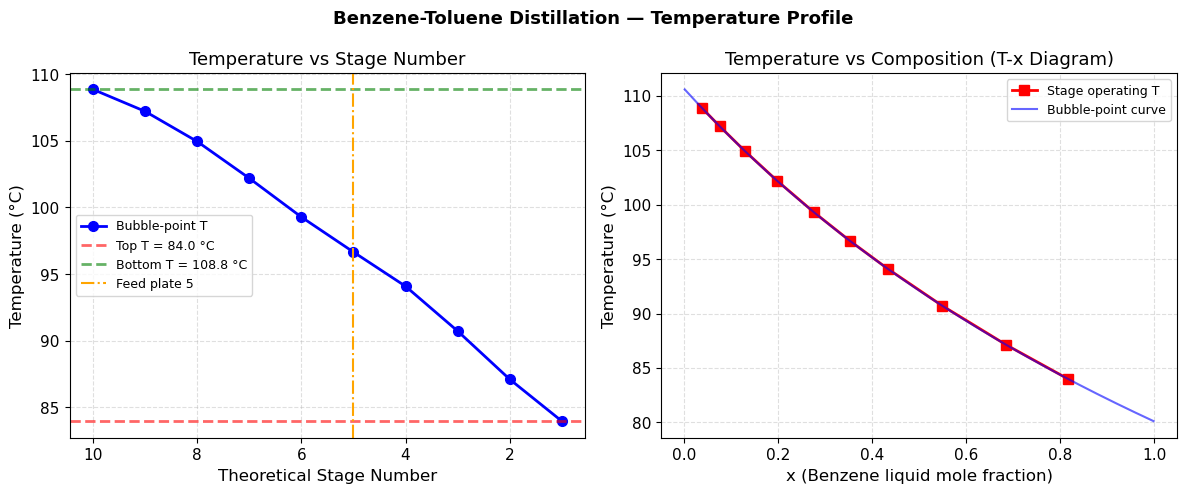

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06\figs\fig_03_temperature_profile.png


In [7]:
# ============================================================
# §6 Temperature Profile
# ============================================================

# Compute bubble-point temperature for each theoretical stage
stage_numbers = [s['n'] for s in stages]
x_stages      = [s['x'] for s in stages]
T_stages      = [bubble_point_T(x) for x in x_stages]

print("=" * 55)
print("  Temperature Profile of Theoretical Stages")
print("=" * 55)
print(f"  {'Stage':>6}  {'x (liquid)':>12}  {'T_bp (°C)':>12}")
print("-" * 55)
for n, x, T in zip(stage_numbers, x_stages, T_stages):
    marker = " ← Feed" if n == feed_plate else ""
    print(f"  {n:>6}  {x:>12.4f}  {T:>12.2f}{marker}")
print("=" * 55)
print(f"\n  Top temperature    (Stage 1)         : {T_stages[0]:.2f} °C")
print(f"  Bottom temperature (Stage {N_stages})        : {T_stages[-1]:.2f} °C")
print(f"  Temperature range                    : {T_stages[-1] - T_stages[0]:.2f} °C")

# ── Temperature Profile Plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Temperature vs Stage Number
ax1 = axes[0]
ax1.plot(stage_numbers, T_stages, 'b-o', linewidth=2, markersize=7, label='Bubble-point T')
ax1.axhline(y=T_stages[0],  color='red',   linestyle='--', alpha=0.6, label=f'Top T = {T_stages[0]:.1f} °C')
ax1.axhline(y=T_stages[-1], color='green', linestyle='--', alpha=0.6, label=f'Bottom T = {T_stages[-1]:.1f} °C')
ax1.axvline(x=feed_plate, color='orange', linestyle='-.', linewidth=1.5, label=f'Feed plate {feed_plate}')
ax1.set_xlabel('Theoretical Stage Number')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature vs Stage Number')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.invert_xaxis()   # Stage 1 (top) on left

# Right: Temperature vs Liquid Composition
ax2 = axes[1]
ax2.plot(x_stages, T_stages, 'r-s', linewidth=2, markersize=7, label='Stage operating T')
# Add bubble and dew point curves
T_bp_curve, T_dp_curve = [], []
x_curve = np.linspace(0.001, 0.999, 200)
for xi in x_curve:
    T_bp_curve.append(bubble_point_T(xi))
T_bp_curve = np.array(T_bp_curve)
ax2.plot(x_curve, T_bp_curve, 'b-', linewidth=1.5, alpha=0.6, label='Bubble-point curve')
ax2.set_xlabel('x (Benzene liquid mole fraction)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Temperature vs Composition (T-x Diagram)')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Benzene-Toluene Distillation — Temperature Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR / 'fig_03_temperature_profile.png'
fig.savefig(fname, dpi=150)
plt.show()
print(f"Saved: {fname}")

---
### 7. 參數研究：回流比對理論板數的影響

**回流比 $R$ 的設計意義：**

回流比是蒸餾塔設計中最重要的操作參數之一，它影響：
- 操作線斜率 → 影響分離推進力
- 理論板數 $N$
- 冷凝器/再沸器熱負荷

**兩個極端情況：**

| 情況 | 回流比 | 特點 |
|------|--------|------|
| 最小回流比 $R_{min}$ | 最小值 | 需要無限多板，操作線通過 Pinch Point |
| 全回流（Total Reflux） | $R \to \infty$ | 板數最少，無產品輸出（Underwood 最小板數 $N_{min}$） |

**Fenske-Underwood-Gilliland 相關（工程估算）：**

$$
\frac{N - N_{min}}{N + 1} = f\left(\frac{R - R_{min}}{R + 1}\right)
$$

其中 $f(\cdot)$ 為 Gilliland 圖關係式（本範例以數值逐級計算取代）。

**本節目標：**
在 $R \in [1.1 R_{min},\ 4.0 R_{min}]$ 範圍內掃描，計算各回流比對應的理論板數 $N$，繪製 $R$ vs $N$ 的關係圖。

R_min = 1.3439
Design R = 2.5000  (R/R_min = 1.86)

         R   R/R_min    N stages    Feed plate
---------------------------------------------
     1.411     1.050          20             9
     1.818     1.353          13             6
     2.224     1.655          11             5
     2.631     1.958          10             5
     3.038     2.260           9             5
     3.444     2.563           9             4
     3.851     2.865           9             4
     4.257     3.168           8             4
     4.664     3.471           8             4
     5.071     3.773           8             4

  Design point: R=2.50, R/R_min=1.86, N=10, Feed=5


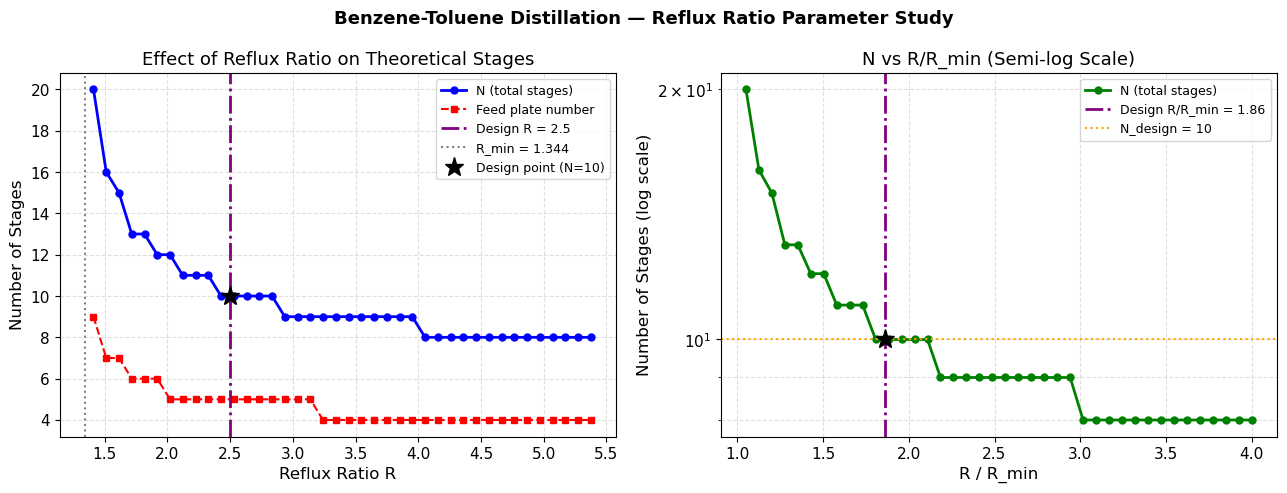

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_06\figs\fig_04_reflux_effect.png


In [8]:
# ============================================================
# §7 Parameter Study: Effect of Reflux Ratio on Theoretical Stages
# ============================================================

R_min_val, _, _ = calc_R_min(x_D, z_F, q)
print(f"R_min = {R_min_val:.4f}")
print(f"Design R = {R:.4f}  (R/R_min = {R/R_min_val:.2f})")
print()

# Sweep R from 1.05*R_min to 4*R_min
n_points = 40
R_range = np.linspace(R_min_val * 1.05, R_min_val * 4.0, n_points)

N_arr        = []
feed_arr     = []
valid_R      = []

for Ri in R_range:
    try:
        stgs, N_i, fp_i = step_mccabe_thiele(x_D, x_B, z_F, Ri, q, max_stages=200)
        N_arr.append(N_i)
        feed_arr.append(fp_i)
        valid_R.append(Ri)
    except Exception:
        pass

N_arr    = np.array(N_arr)
feed_arr = np.array(feed_arr)
valid_R  = np.array(valid_R)

# Print table summary (every 5 points)
print(f"  {'R':>8}  {'R/R_min':>8}  {'N stages':>10}  {'Feed plate':>12}")
print("-" * 45)
for i in range(0, len(valid_R), max(1, len(valid_R)//10)):
    print(f"  {valid_R[i]:>8.3f}  {valid_R[i]/R_min_val:>8.3f}  {N_arr[i]:>10d}  {feed_arr[i]:>12d}")

# Highlight design point
_, N_design, feed_design = step_mccabe_thiele(x_D, x_B, z_F, R, q)
print(f"\n  Design point: R={R:.2f}, R/R_min={R/R_min_val:.2f}, N={N_design}, Feed={feed_design}")

# ── Reflux Ratio Effect Plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: N vs R
ax1 = axes[0]
ax1.plot(valid_R, N_arr, 'b-o', linewidth=2, markersize=5, label='N (total stages)')
ax1.plot(valid_R, feed_arr, 'r--s', linewidth=1.5, markersize=5, label='Feed plate number')
ax1.axvline(x=R, color='purple', linestyle='-.', linewidth=2, label=f'Design R = {R}')
ax1.axvline(x=R_min_val, color='gray', linestyle=':', linewidth=1.5, label=f'R_min = {R_min_val:.3f}')
ax1.plot(R, N_design, 'k*', markersize=14, zorder=5, label=f'Design point (N={N_design})')
ax1.set_xlabel('Reflux Ratio R')
ax1.set_ylabel('Number of Stages')
ax1.set_title('Effect of Reflux Ratio on Theoretical Stages')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Right: N vs R/R_min (Gilliland-style plot)
ax2 = axes[1]
R_ratio = valid_R / R_min_val
ax2.semilogy(R_ratio, N_arr, 'g-o', linewidth=2, markersize=5, label='N (total stages)')
ax2.axvline(x=R/R_min_val, color='purple', linestyle='-.', linewidth=2,
            label=f'Design R/R_min = {R/R_min_val:.2f}')
ax2.axhline(y=N_design, color='orange', linestyle=':', linewidth=1.5,
            label=f'N_design = {N_design}')
ax2.plot(R/R_min_val, N_design, 'k*', markersize=14, zorder=5)
ax2.set_xlabel('R / R_min')
ax2.set_ylabel('Number of Stages (log scale)')
ax2.set_title('N vs R/R_min (Semi-log Scale)')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, which='both')

plt.suptitle('Benzene-Toluene Distillation — Reflux Ratio Parameter Study',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR / 'fig_04_reflux_effect.png'
fig.savefig(fname, dpi=150)
plt.show()
print(f"Saved: {fname}")

---
### 8. 總結（Summary）

**本範例求解流程：**

```
1. Antoine 方程式 + Raoult's Law → VLE 相平衡曲線
       ↓
2. 物料平衡 → 精餾段操作線、汽提段操作線
       ↓
3. 最小回流比 R_min（Pinch Point 分析）
       ↓
4. 給定 R = 2.5 → 逐級步進計算理論板數
       ↓
5. 各板泡點溫度 → 塔溫度分布
       ↓
6. 回流比參數研究 → R vs N 關係
```

**設計結果彙整（苯-甲苯系統，760 mmHg）：**

| 參數 | 數值 |
|------|------|
| 進料組成 $z_F$ | 0.40 (mol/mol 苯) |
| 塔頂規格 $x_D$ | 0.92 |
| 塔底規格 $x_B$ | 0.05 |
| 進料熱狀態 $q$ | 1.0（飽和液進料） |
| 最小回流比 $R_{min}$ | 1.3439 |
| 設計回流比 $R$ | 2.5 |
| 理論板數 $N$ | 10（含再沸器） |
| 最佳進料板 | 第 5 板 |

**學習重點：**

1. **VLE 計算**：Antoine 方程式 + 泡點求解（`root_scalar`/Brentq）
2. **操作線方程式**：精餾段斜率 $\frac{R}{R+1}$，汽提段由物料平衡推導
3. **McCabe-Thiele 步進算法**：雙層迭代非線性求解（`find_x_from_y_eq`）
4. **進料板位置**：在 $x_{int}$ 附近切換操作線
5. **回流比影響**：$R \uparrow$ → 操作線斜率上升 → 板數減少，但能耗增加

**工程應用延伸：**
- Murphree 效率（板效率 $E_{MV}$）的引入
- 多組份蒸餾（Fenske-Underwood-Gilliland 方法）
- 連續模擬工具（如 Aspen Plus、HYSYS）的驗證